In [1]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter
df=pd.read_csv("blc_cleaned.csv")
df.head()

,S.No.,Country,City,Company,Contact,Maps,Category,Standard_Category,Rank,Conversion_Probability,Predicted_Probability,Rating,Review
0,1,USA,San Francisco,Andrew Dental Clinic San Francisco,'12294541223,https://www.google.com/maps/place/Andrew+Denta...,Dentist,Dental Clinic,5.0,0.85,0.850567,0.0,0
1,2,USA,San Francisco,San Francisco Dental Artistry,'14153990609,https://www.google.com/maps/place/San+Francisc...,Dentist,Dental Clinic,5.0,0.85,0.849368,3.7,74
2,3,India,Haryana,FAMILY DENTAL AND COSMETIC CLINIC,'8708512323,https://www.google.com/maps/place/FAMILY+DENTA...,Hospital,Hospital,10.0,0.55,0.544297,4.9,14
3,4,India,Haryana,Shree Ram Clinic,'7206042912,https://www.google.com/maps/place/Shree+Ram+Cl...,Medical Clinic,Medical Clinic,4.0,0.85,0.859486,5.0,7
4,5,India,Haryana,Sunil's health and wellness physiotherapy clin...,'9992849288,https://www.google.com/maps/place/Sunil's+heal...,Medical Clinic,Medical Clinic,4.0,0.85,0.844350,4.7,11


In [2]:
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce').fillna(0.0)
df['Review'] = pd.to_numeric(df['Review'], errors='coerce').fillna(0.0)

df['Rating_Normalized'] = df['Rating']/5
max_review = df['Review'].max()
df['Review_Normalized'] = np.log1p(df['Review']) / np.log1p(max_review)
df['Lead_Score'] = (df['Review_Normalized'] + df['Rating_Normalized'])/2

print(df[['Company', 'Rating', 'Review', 'Rating_Normalized', 'Review_Normalized', 'Lead_Score']].head(10))

                                             Company  Rating  Review  \
0                 Andrew Dental Clinic San Francisco     0.0       0   
1                      San Francisco Dental Artistry     3.7      74   
2                  FAMILY DENTAL AND COSMETIC CLINIC     4.9      14   
3                                   Shree Ram Clinic     5.0       7   
4  Sunil's health and wellness physiotherapy clin...     4.7      11   
5                       Dr. Vidya Homeopathic Clinic     5.0       2   
6                                      JJMB HOSPITAL     4.1      97   
7                     Vaidik Dental & Aesthetic Care     5.0     274   
8  Shri Mata Sheetla Dental Clinic and Implant Ce...     4.9      90   
9  Armaan Dental Clinic & Smile Center - Dental C...     4.8     397   

   Rating_Normalized  Review_Normalized  Lead_Score  
0               0.00           0.000000    0.000000  
1               0.74           0.564435    0.652218  
2               0.98           0.354030    0.

In [3]:
df['Final_Score'] = (df['Conversion_Probability'] * 0.6) + (df['Lead_Score'] * 0.4)

print(df[['Company', 'Standard_Category', 'Conversion_Probability', 'Lead_Score', 'Final_Score']].head(10))

                                             Company Standard_Category  \
0                 Andrew Dental Clinic San Francisco     Dental Clinic   
1                      San Francisco Dental Artistry     Dental Clinic   
2                  FAMILY DENTAL AND COSMETIC CLINIC          Hospital   
3                                   Shree Ram Clinic    Medical Clinic   
4  Sunil's health and wellness physiotherapy clin...    Medical Clinic   
5                       Dr. Vidya Homeopathic Clinic    Medical Clinic   
6                                      JJMB HOSPITAL    Medical Clinic   
7                     Vaidik Dental & Aesthetic Care     Dental Clinic   
8  Shri Mata Sheetla Dental Clinic and Implant Ce...          Hospital   
9  Armaan Dental Clinic & Smile Center - Dental C...     Dental Clinic   

   Conversion_Probability  Lead_Score  Final_Score  
0                    0.85    0.000000     0.510000  
1                    0.85    0.652218     0.770887  
2                    0.55 

In [4]:
df["Company_Name_Length"] = df["Company"].str.len()
df["Company_Word_Count"] = df["Company"].str.split().str.len()

category_counts_dict = df["Standard_Category"].value_counts().to_dict()
df["Category_Frequency"] = df["Standard_Category"].map(category_counts_dict)

City_counts_dict = df["City"].value_counts().to_dict()
df["City_Frequency"] = df["City"].map(City_counts_dict)

le_city = LabelEncoder()
df["City_Encoded"] = le_city.fit_transform(df["City"])

le_category = LabelEncoder()
df["Category_Encoded"] = le_category.fit_transform(df["Standard_Category"])

print("Features created!")
print(df[["Company_Name_Length", "Company_Word_Count", "Category_Frequency", "City_Frequency"]].head())

Features created!
   Company_Name_Length  Company_Word_Count  Category_Frequency  City_Frequency
0                   34                   5                  20              12
1                   29                   4                  20              12
2                   33                   5                  25              68
3                   16                   3                  24              68
4                   56                   7                  24              68


In [5]:
group_counts = df.groupby('Standard_Category').size()
df['Group_Size'] = df['Standard_Category'].map(group_counts)
df['Sample_Weight'] = 1 / df['Group_Size']

feature_names = ["Company_Name_Length", "Company_Word_Count",
                 "Category_Frequency", "City_Frequency",
                 "Rating_Normalized", "Review_Normalized","Conversion_Probability", "Lead_Score"]

print("Features created!")
print(df[feature_names].head())

Features created!
   Company_Name_Length  Company_Word_Count  Category_Frequency  \
0                   34                   5                  20   
1                   29                   4                  20   
2                   33                   5                  25   
3                   16                   3                  24   
4                   56                   7                  24   

   City_Frequency  Rating_Normalized  Review_Normalized  \
0              12               0.00           0.000000   
1              12               0.74           0.564435   
2              68               0.98           0.354030   
3              68               1.00           0.271850   
4              68               0.94           0.324858   

   Conversion_Probability  Lead_Score  
0                    0.85    0.000000  
1                    0.85    0.652218  
2                    0.55    0.667015  
3                    0.85    0.635925  
4                    0.85    0

In [6]:
mask = df['Group_Size'] >= 2
df_for_split = df[mask]
df_excluded = df[~mask]

X_split = df_for_split[feature_names]
y_split = df_for_split["Final_Score"]
w_split = df_for_split["Sample_Weight"]
strat_key = df_for_split["Standard_Category"]

X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X_split, y_split, w_split,
    test_size=0.2, random_state=42,
    stratify=strat_key
)

print(f"Training samples: {len(X_train)}, Test samples: {len(X_test)}")
print(f"Excluded (rare categories): {len(df_excluded)}")

print("\ndepth | train_score | test_score")
print("-" * 40)
for i in range(1, 12):
    xgb_temp = XGBRegressor(n_estimators=500, max_depth=i, random_state=42, learning_rate=0.1)
    xgb_temp.fit(X_train, y_train, sample_weight=w_train)
    print(f"  {i}   |   {xgb_temp.score(X_train, y_train):.4f}   |   {xgb_temp.score(X_test, y_test):.4f}")

Training samples: 158, Test samples: 40
Excluded (rare categories): 2

depth | train_score | test_score
----------------------------------------
  1   |   0.9961   |   0.9963
  2   |   0.9960   |   0.9587
  3   |   0.9979   |   0.9719
  4   |   0.9979   |   0.9699
  5   |   0.9980   |   0.9702
  6   |   0.9980   |   0.9705
  7   |   0.9980   |   0.9705
  8   |   0.9980   |   0.9705
  9   |   0.9980   |   0.9705
  10   |   0.9980   |   0.9705
  11   |   0.9980   |   0.9705


In [7]:
print("n_estimators | train_score | test_score")
print("-" * 45)
for n in [50, 100, 150, 200, 300, 500, 700, 1000,1200]:
    xgb_temp = XGBRegressor(n_estimators=n, max_depth=6, random_state=42, learning_rate=0.1)
    xgb_temp.fit(X_train, y_train, sample_weight=w_train)
    print(f"  {n}   |   {xgb_temp.score(X_train, y_train):.4f}   |   {xgb_temp.score(X_test, y_test):.4f}")

n_estimators | train_score | test_score
---------------------------------------------
  50   |   0.9645   |   0.8968
  100   |   0.9839   |   0.9346
  150   |   0.9902   |   0.9496
  200   |   0.9933   |   0.9577
  300   |   0.9964   |   0.9656
  500   |   0.9980   |   0.9705
  700   |   0.9980   |   0.9705
  1000   |   0.9980   |   0.9705
  1200   |   0.9980   |   0.9705


In [8]:
xgb_model = XGBRegressor(n_estimators=500, max_depth=6, random_state=42, learning_rate=0.1)
xgb_model.fit(X_train, y_train, sample_weight=w_train)

df["Final_Predicted_Score"] = xgb_model.predict(df[feature_names])

print(f"Final Train R²: {xgb_model.score(X_train, y_train):.4f}")
print(f"Final Test R²: {xgb_model.score(X_test, y_test):.4f}")
print(df[['Company', 'Standard_Category', 'Conversion_Probability',
          'Lead_Score', 'Final_Score', 'Final_Predicted_Score']].head(10))

Final Train R²: 0.9980
Final Test R²: 0.9705
                                             Company Standard_Category  \
0                 Andrew Dental Clinic San Francisco     Dental Clinic   
1                      San Francisco Dental Artistry     Dental Clinic   
2                  FAMILY DENTAL AND COSMETIC CLINIC          Hospital   
3                                   Shree Ram Clinic    Medical Clinic   
4  Sunil's health and wellness physiotherapy clin...    Medical Clinic   
5                       Dr. Vidya Homeopathic Clinic    Medical Clinic   
6                                      JJMB HOSPITAL    Medical Clinic   
7                     Vaidik Dental & Aesthetic Care     Dental Clinic   
8  Shri Mata Sheetla Dental Clinic and Implant Ce...          Hospital   
9  Armaan Dental Clinic & Smile Center - Dental C...     Dental Clinic   

   Conversion_Probability  Lead_Score  Final_Score  Final_Predicted_Score  
0                    0.85    0.000000     0.510000              

In [9]:
df_sorted = df.sort_values(
    by=['Final_Predicted_Score', 'Rating', 'Review'],
    ascending=[False, False, False]
).reset_index(drop=True)

total = len(df_sorted)
high_cutoff = int(total * 0.28)
medium_cutoff = int(total * 0.65)

high_priority = df_sorted.iloc[0:high_cutoff].copy()
medium_priority = df_sorted.iloc[high_cutoff:medium_cutoff].copy()
low_priority = df_sorted.iloc[medium_cutoff:total].copy()

print(f"High: {len(high_priority)}, Medium: {len(medium_priority)}, Low: {len(low_priority)}")

High: 56, Medium: 74, Low: 70


In [10]:
columns_to_export = [
    "S.No.",
    "Country",
    "City",
    "Company",
    "Contact",
    "Maps",
    "Category",
    "Final_Predicted_Score"
]

high_priority_final = high_priority[columns_to_export]
medium_priority_final = medium_priority[columns_to_export]
low_priority_final = low_priority[columns_to_export]

wb = openpyxl.Workbook()
wb.remove(wb.active)

sheets_config = {
    f"High Priority ({len(high_priority)})": (high_priority_final, "1A6B3A"),
    f"Medium Priority ({len(medium_priority)})": (medium_priority_final, "B8860B"),
    f"Low Priority ({len(low_priority)})": (low_priority_final, "8B3A3A")
}

for sheet_name, (sub_df, header_color) in sheets_config.items():
    ws = wb.create_sheet(title=sheet_name)
    ws.views.sheetView[0].showGridLines = False

    headers = list(sub_df.columns)
    ws.append(headers)

    header_font = Font(name="Calibri", size=11, bold=True, color="FFFFFF")
    header_fill = PatternFill(start_color=header_color, end_color=header_color, fill_type="solid")
    center_align = Alignment(horizontal="center", vertical="center", wrap_text=True)
    left_align = Alignment(horizontal="left", vertical="center")
    thin_border = Border(
        left=Side(style="thin", color="D9D9D9"),
        right=Side(style="thin", color="D9D9D9"),
        top=Side(style="thin", color="D9D9D9"),
        bottom=Side(style="thin", color="D9D9D9")
    )
    row_fill_even = PatternFill(start_color="F2F6FA", end_color="F2F6FA", fill_type="solid")
    row_fill_odd = PatternFill(start_color="FFFFFF", end_color="FFFFFF", fill_type="solid")

    for col_num, header in enumerate(headers, 1):
        cell = ws.cell(row=1, column=col_num)
        cell.font = header_font
        cell.fill = header_fill
        cell.alignment = center_align
        cell.border = thin_border
    ws.row_dimensions[1].height = 28

    for r_idx, row_data in enumerate(sub_df.values, 2):
        row_fill = row_fill_even if r_idx % 2 == 0 else row_fill_odd
        for c_idx, value in enumerate(row_data, 1):
            current_header = headers[c_idx - 1]

            if current_header == "Contact":
                clean_contact = str(value).strip() if pd.notna(value) else ""
                clean_contact = "" if clean_contact.lower() in ["nan", "none", ""] else clean_contact
                clean_contact = clean_contact.lstrip("'")
                cell = ws.cell(row=r_idx, column=c_idx)
                cell.value = clean_contact if clean_contact else ""
                cell.data_type = "s"
                cell.number_format = "@"
                cell.alignment = center_align
                cell.border = thin_border
                cell.font = Font(name="Calibri", size=10.5)
                cell.fill = row_fill
                continue

            cell = ws.cell(row=r_idx, column=c_idx, value=value)
            cell.border = thin_border
            cell.font = Font(name="Calibri", size=10.5)
            cell.fill = row_fill

            if current_header in ["S.No", "Rank"]:
                cell.alignment = center_align
            elif current_header == "Final_Predicted_Score":
                cell.alignment = center_align
                cell.number_format = "0.0%"
                if isinstance(value, (int, float)):
                    if value >= 0.70:
                        cell.font = Font(name="Calibri", size=10.5, bold=True, color="1E7C3A")
                    elif value <= 0.30:
                        cell.font = Font(name="Calibri", size=10.5, color="A6A6A6")
            elif current_header == "Maps":
                cell.alignment = left_align
                if pd.notna(value) and str(value).startswith("http"):
                    cell.hyperlink = str(value)
                    cell.font = Font(name="Calibri", size=10.5, color="0563C1", underline="single", bold=True)
                else:
                    cell.value = "N/A"
                    cell.font = Font(name="Calibri", size=10.5, color="A6A6A6")
            else:
                cell.alignment = left_align

        ws.row_dimensions[r_idx].height = 20

    for col in ws.columns:
        max_len = max(len(str(cell.value or "")) for cell in col)
        col_letter = get_column_letter(col[0].column)
        ws.column_dimensions[col_letter].width = max(max_len + 3, 12)

    ws.freeze_panes = "A2"
    ws.auto_filter.ref = ws.dimensions

wb.save("Reviews_Rating_based_leads.xlsx")
print("\n--- PROCESS COMPLETE ---")
print("Successfully generated 'Reviews_Rating_based_leads.xlsx' with High/Medium/Low priority sheets!")


--- PROCESS COMPLETE ---
Successfully generated 'Reviews_Rating_based_leads.xlsx' with High/Medium/Low priority sheets!


       Standard_Category      mean  count
8        Training Center  0.802753     32
0          Dental Clinic  0.795581     16
1        ENT & Audiology  0.790838     10
5         Medical Clinic  0.776417     22
6  Physiotherapy & Rehab  0.765351     22
7      Speciality Clinic  0.667493     11
2               Eye Care  0.638923      7
4               Hospital  0.631951      9


/tmp/ipykernel_2178/3535524839.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


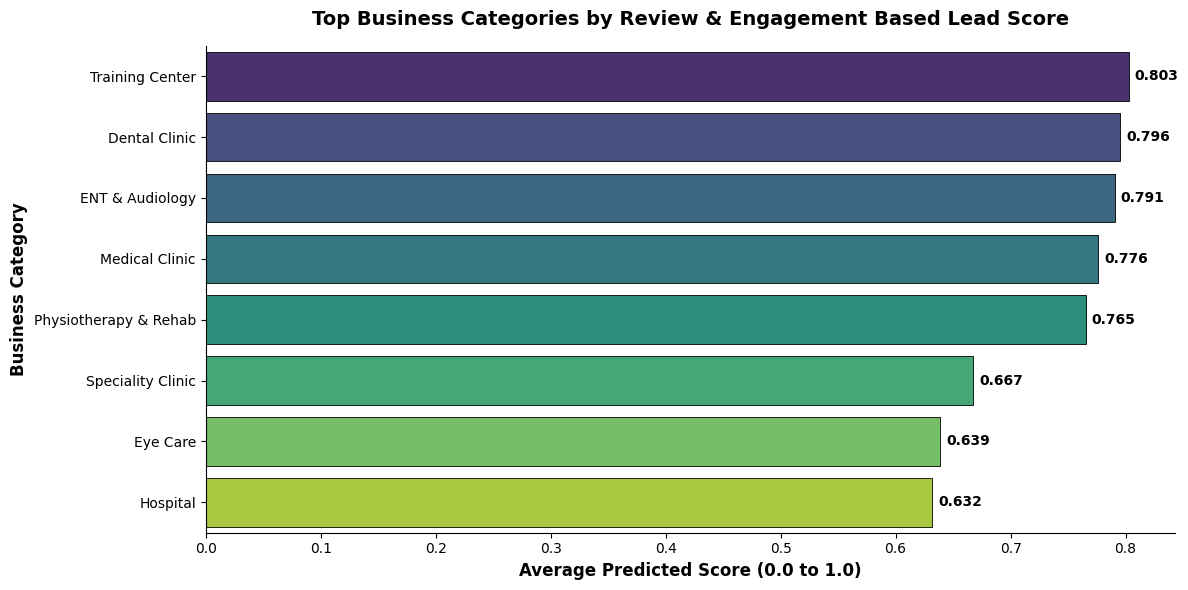

Graph saved successfully.


In [11]:
visualization_df = df_sorted.iloc[0:medium_cutoff].copy()

category_stats = visualization_df.groupby('Standard_Category')['Final_Predicted_Score'].agg(['mean', 'count']).reset_index()
category_stats_filtered = category_stats[category_stats['count'] >= 3].sort_values(by='mean', ascending=False).head(10)

print(category_stats_filtered)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(
    data=category_stats_filtered,
    x='mean',
    y='Standard_Category',
    palette='viridis',
    ax=ax,
    edgecolor='black',
    linewidth=0.6
)

ax.set_title('Top Business Categories by Review & Engagement Based Lead Score', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Average Predicted Score (0.0 to 1.0)', fontsize=12, fontweight='bold')
ax.set_ylabel('Business Category', fontsize=12, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)

for i, v in enumerate(category_stats_filtered['mean']):
    ax.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('top_categories_by_engagement_score.png', dpi=300)
plt.show()
print("Graph saved successfully.")